1.Analyse exploratoire des données (EDA)
1.A Chargement et Inspection

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier


data = pd.read_csv("diabetes.csv")

ModuleNotFoundError: No module named 'seaborn'

In [68]:
#Affichage des 5 premières lignes
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [69]:
#Vérification des dimensions
data.shape

(768, 9)

In [70]:
#Examiner les types de variables
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [71]:
#Statistiques descriptives
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


1.B Analyse des valeurs manquantes

In [72]:
#comptage du nombre de valeurs nulles dans chaque variable
(data == 0).sum()


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

la commande ci-dessus permet de juste comptre le nombre de fois que l'on voit des valeurs nulles dans le dataset. Et certaines variables telles que Pregnancies et outcome peuvent contenir des valeurs nulles mais pour les autres variables ces valeurs ne sont pas cohérentes. Nous allons faire une autre commande qui nous premettra de nous concentrer que sur les variables pouvant contenir des données manquantes.

In [73]:
#Valeur Manquantes
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Stratégie de traitement des valeurs incohérentes
    Certaines variables de ce dataset contiennent des valeurs inchohérentes car dans un contexte médical, elles sont physiologiquement impossible, donc on peut aussi dire que ce sont des données manquantes. 
    On peut envisager plusieurs stratégies de traitements, comme la suppression des patients avec des données à valeurs manquantes mais cela nous ferait perdre beaucoup de données.
    Mais la stratégie la plus sûre serait de remplacer les valeurs manquantes par la médiane car elle est moins sensibles au valeurs extrêmes et nous pourrons ainsi conserver l'ensemble des observations du dataset.


In [74]:
#Moyenne, médiane, variance (NumPy)

columns= data.columns

for clm in columns:
    col_values = data[clm].values 
    moyenne = np.mean(col_values)
    mediane = np.median(col_values)
    variance = np.var(col_values)

    print(f"Colonne : {clm}")
    print("Moyenne: ", moyenne)
    print("Médiane: ", mediane)
    print("Variance: ", variance)
    print("___________________________")
    print("")


Colonne : Pregnancies
Moyenne:  3.8450520833333335
Médiane:  3.0
Variance:  11.339272393120657
___________________________

Colonne : Glucose
Moyenne:  120.89453125
Médiane:  117.0
Variance:  1020.9172617594401
___________________________

Colonne : BloodPressure
Moyenne:  69.10546875
Médiane:  72.0
Variance:  374.1594492594401
___________________________

Colonne : SkinThickness
Moyenne:  20.536458333333332
Médiane:  23.0
Variance:  254.14189995659726
___________________________

Colonne : Insulin
Moyenne:  79.79947916666667
Médiane:  30.5
Variance:  13263.886874728734
___________________________

Colonne : BMI
Moyenne:  31.992578124999998
Médiane:  32.0
Variance:  62.079046478271486
___________________________

Colonne : DiabetesPedigreeFunction
Moyenne:  0.47187630208333325
Médiane:  0.3725
Variance:  0.10963569693840876
___________________________

Colonne : Age
Moyenne:  33.240885416666664
Médiane:  29.0
Variance:  138.12296379937067
___________________________

Colonne : Outcome


In [75]:
#Corrélation entre variables
correlation = data.corr()
# print (correlation)
# print (correlation)
corr = correlation.values 

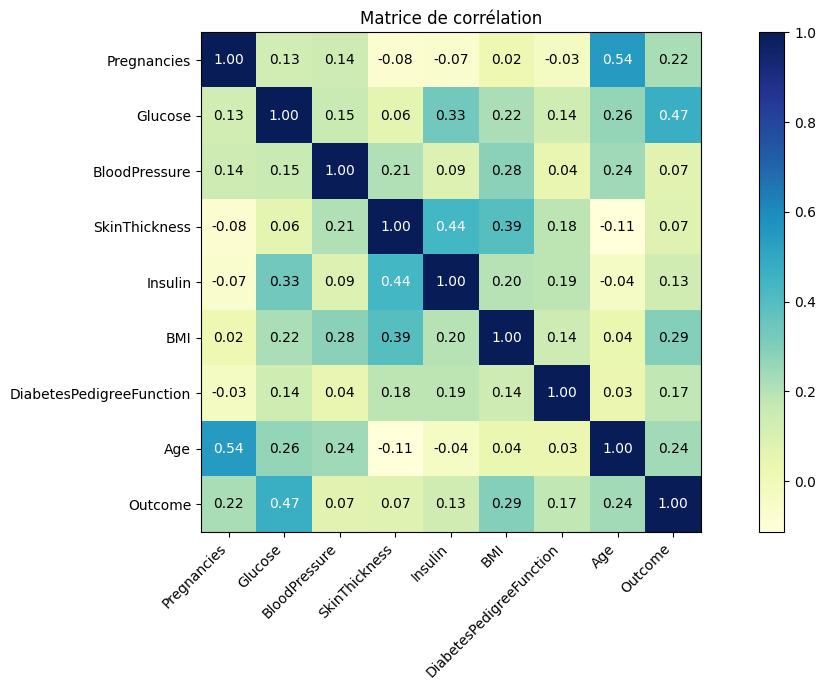

In [76]:
#Matrice de corrélation

plt.figure(figsize=(12,7))
plt.imshow(corr, cmap='YlGnBu', interpolation='none')  
plt.colorbar()

plt.xticks(range(len(data.columns)), data.columns, rotation=45, ha='right')
plt.yticks(range(len(data.columns)), data.columns, rotation=0)

# Texte avec condition de couleur
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr[i,j]
        color = 'white' if 0.4 <= val <= 1 else 'black' 
        plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color)

plt.title("Matrice de corrélation")
plt.tight_layout() 
plt.show()

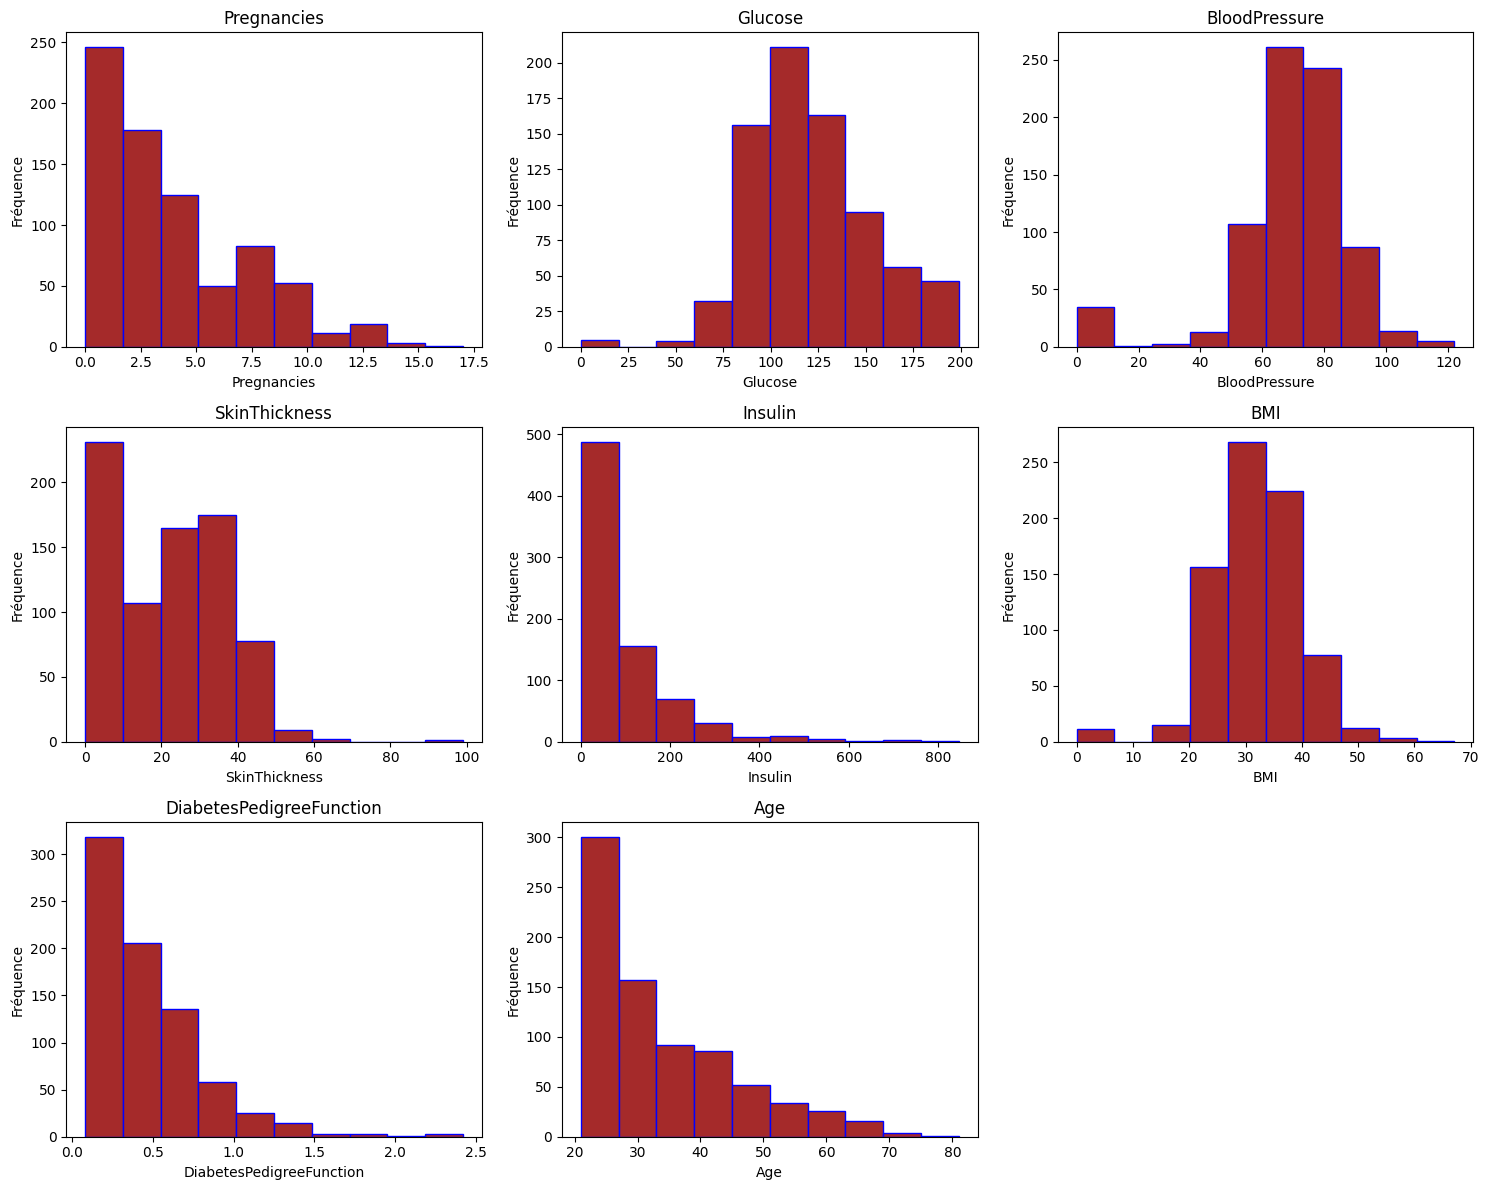

In [77]:
 #Histogrammes des variables


columns = data.columns.drop("Outcome") 
n_cols = 3  
n_rows = (len(columns) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].hist(data[col], bins=10, color="brown", edgecolor="blue")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
plt.show()

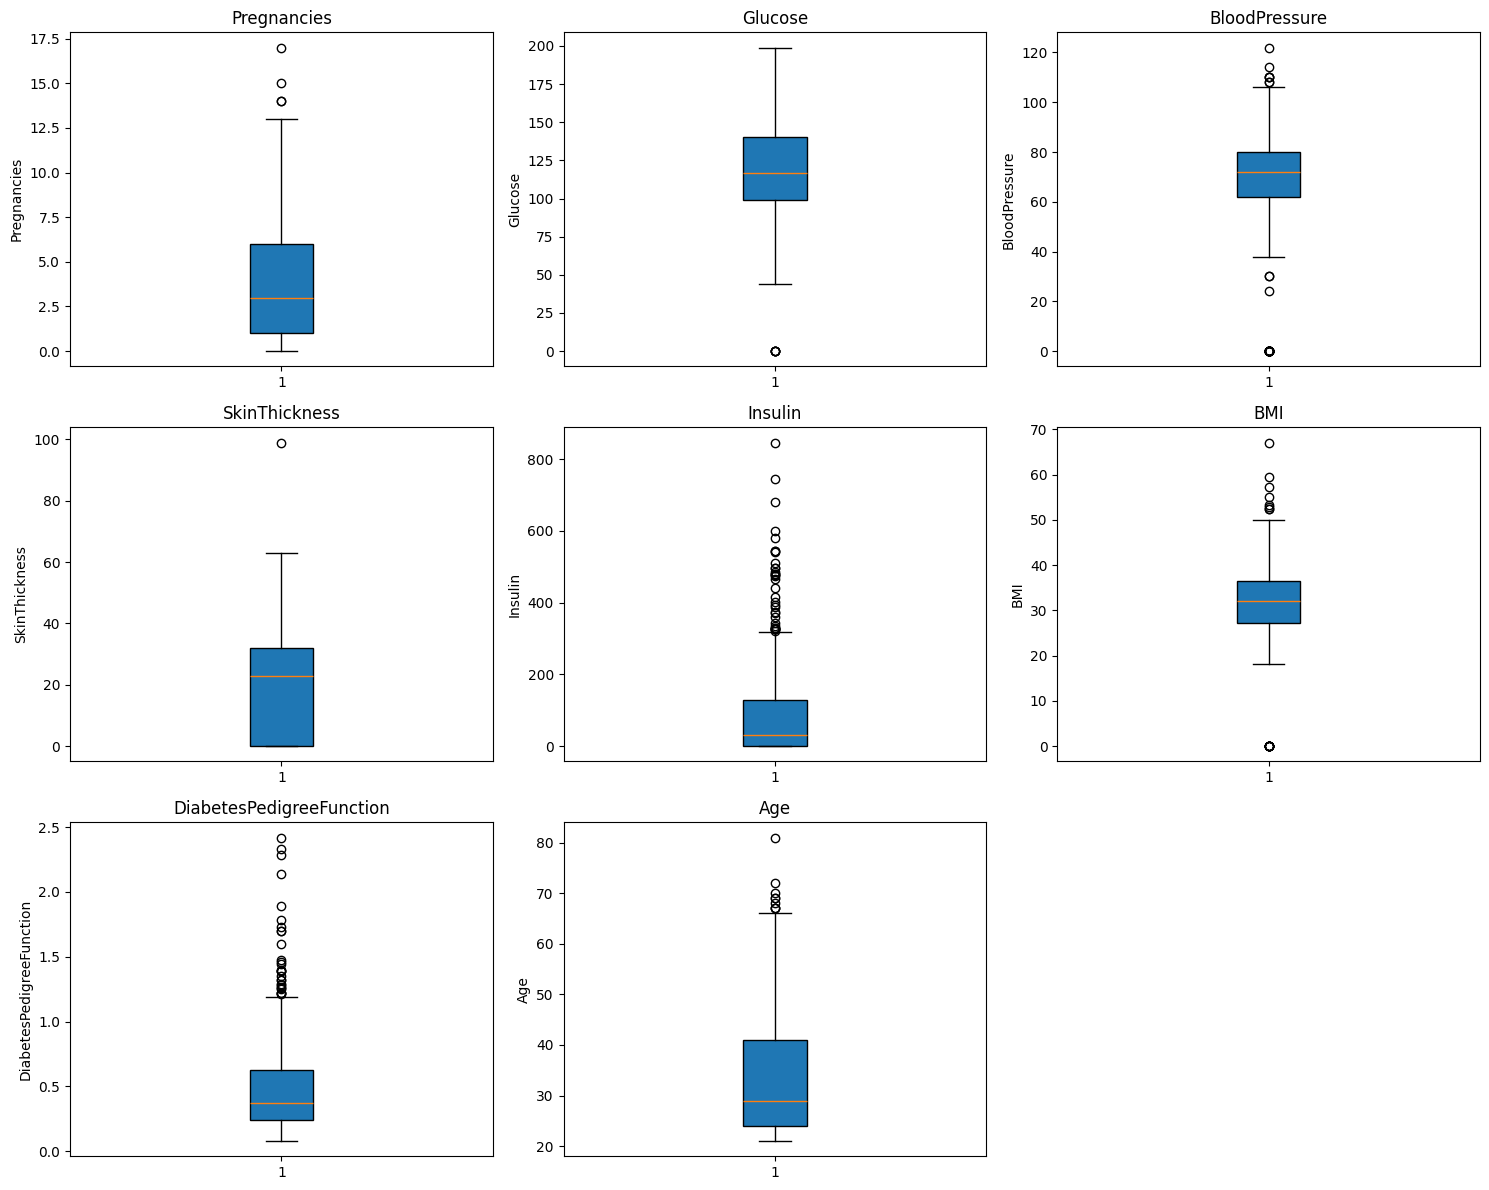

In [78]:
#Diagrammes en boîte (boxplots)


columns = data.columns.drop("Outcome") 
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].boxplot(data[col], patch_artist=True)
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

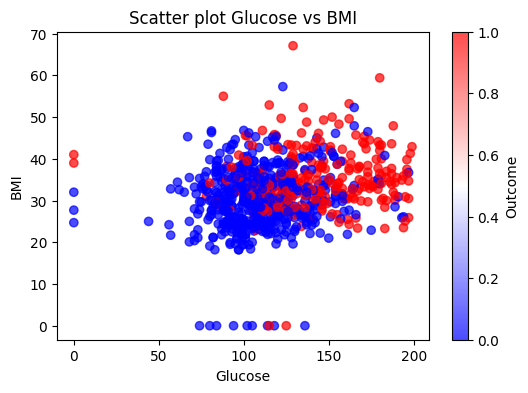

In [79]:
#Scatter plots pertinents
plt.figure(figsize=(6,4))
plt.scatter(data['Glucose'], data['BMI'], c=data['Outcome'], cmap='bwr', alpha=0.7)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Scatter plot Glucose vs BMI')
plt.colorbar(label='Outcome')
plt.show()

2. Prétraitement Des Données

2.1 Nettoyage des données

In [80]:
#remplacer les valeurs manquantes par NaN
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

data[cols]= data[cols].replace(0, np.nan)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [81]:
#Remplacer les données manquantes

for col in cols:
    data[col] = data[col].fillna(data[col].median())
#vérification
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Les valeurs manquantes ont été remplacées par la médiane de chaque variable. Cette méthode a été choisie car la médiane est moins sensible aux valeurs aberrantes que la moyenne et permet de préserver la distribution des données.

2.2 Gestion des valeurs aberrantes

In [82]:
columns= data.columns.drop("Outcome")

for col in cols:
    
     Q1 = data[col].quantile(0.25)
     Q3 = data[col].quantile(0.75)
     IQR = Q3 - Q1
    
     lower = Q1 - 1.5 * IQR
     upper = Q3 + 1.5 * IQR
    
     data[col] = data[col].clip(lower, upper)

Les valeurs aberrantes ont été identifiées à l’aide de la méthode de l’intervalle interquartile (IQR). Les observations situées en dehors de l’intervalle "Q1 - 1.5 * IQR, Q3 + 1.5 * IQR"
ont été considérées comme des outliers. Afin de limiter leur impact sur l’apprentissage du modèle tout en conservant les observations, la méthode de capping a été utilisée pour ramener les valeurs extrêmes aux bornes définies.

2.4 Séparation des données train / test

In [83]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

2.3 Normalisation ou Standardisation 

In [84]:
scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)

X_test_scaler = scaler.transform(X_test)

La standardisation a été appliquée uniquement sur les données d’entraînement afin d’éviter toute fuite de données (data leakage), raison pour laquelle nous avons d'abord procédé à la sparation des données. Les paramètres de transformation (moyenne et écart-type) ont ensuite été appliqués aux données de test. Cette approche garantit une évaluation plus réaliste des performances du modèle.
Bien que la normalisation aurait pu être utilisée après le traitement des valeurs aberrantes, la standardisation a été privilégiée car elle est généralement plus robuste aux distributions asymétriques et plus adaptée à de nombreux algorithmes de machine learning.

3. Modélisation

3.1  Logistic Regression

La régression logistique est un modèle de classification qui permet de prédire une probabilité. Il combine les variables pour calculer les probabilités

In [85]:
model_lr = LogisticRegression (max_iter=1000)

model_lr.fit(X_train_scaler,y_train)

#Predict
y_pred_train_lr = model_lr.predict(X_train_scaler)
y_pred_lr = model_lr.predict(X_test_scaler)

La régression logistique est un modèle de classification qui estime la probabilité qu’une observation appartienne à une classe donnée. Dans notre cas, elle permet de prédire la probabilité qu’un patient soit diabétique. Si cette probabilité dépasse un certain seuil (généralement 0.5), le patient est classé comme diabétique. Ce modèle est simple et interprétable

3.2 Random Forest


Le Random Forest est un ensemble de plusieurs arbres de décision. Chaque arbre apprend  sur une partie différente des données et fait sa propre prédiction et ensuite on prend la majorité des votes comme résultat.

In [86]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,  
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train_scaler , y_train)

#Prediction
y_pred_train_rf= rf_model.predict (X_train_scaler)
y_pred_rf = rf_model.predict(X_test_scaler)



Le modèle Random Forest est un ensemble d’arbres de décision qui permet d’améliorer la robustesse et la précision des prédictions en combinant les résultats de plusieurs arbres. Il réduit le risque de surapprentissage et offre de bonnes performances sur des données complexes.

3.3 K-Nearest Neighbors (KNN)

Le KNN n'apprend pas vraiment, il regarde les K voisins les plus proches pour donner un résultat.

In [87]:
knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaler, y_train)

#Prediction
y_pred_train_knn= knn_model.predict (X_train_scaler)
y_pred_knn = knn_model.predict(X_test_scaler)

Le modèle KNN repose sur le principe de similarité entre les observations. Il classe une nouvelle observation en fonction des classes de ses plus proches voisins. Ce modèle nécessite une standardisation des données car il est basé sur des distances.

3.4 XGBoost (XGB)

C'est un algorithme de boosting qui construit une série d'arbres de décision de manière séquentielle. chaque arbre est entrainé pour corriger l'erreur du précédent. Il utilise la descente de gradient pour minimiser l'écart entre ses prédictions et la réalité

In [88]:


model_xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,      
    reg_lambda=1,       
    random_state=42,
    eval_metric='logloss'
)

# Train
model_xgb.fit(X_train_scaler, y_train)

# Prédict
y_pred_xgb = model_xgb.predict(X_test_scaler)
y_pred_train_xgb = model_xgb.predict(X_train_scaler)



4.Evaluation des performances

4.1 Accuracy

In [89]:
#RandomForest
print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Random Forest Accuracy Train: ", accuracy_score(y_train, y_pred_train_rf))

#KNN
print("KNN Accuracy: ", accuracy_score(y_test, y_pred_knn))

#Logistic Regression
print("Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred_lr))

#XGB
#print("XGBoost Accuracy Train: ", accuracy_score(y_train, y_pred_train_xgb))
print("XGBoost Accuracy Test: ", accuracy_score(y_test, y_pred_xgb))

Random Forest Accuracy:  0.7792207792207793
Random Forest Accuracy Train:  1.0
KNN Accuracy:  0.7272727272727273
Logistic Regression Accuracy:  0.7337662337662337


NameError: name 'y_pred_xgb' is not defined

L’accuracy mesure la proportion de prédictions correctes réalisées par le modèle. Dans notre cas, le modèle Random Forest présente la meilleure accuracy (77.9%), indiquant une meilleure performance globale. La régression logistique (73.3%) et KNN (72.7%) affichent des résultats proches, mais légèrement inférieurs.


4.2 Précision

In [90]:
#Random Forest
print(f"Precision Random Forest:", precision_score(y_test, y_pred_rf))

#KNN
print(f"Precision KNN: {precision_score(y_test, y_pred_knn):.4f}")

#Logistic Regression
print(f"Precision Logistic Regression: {precision_score(y_test, y_pred_lr):.4f}")

#XGB
print(f"Precision XGBoost: {precision_score(y_test, y_pred_xgb):.4f}")

Precision Random Forest: 0.68
Precision KNN: 0.6066
Precision Logistic Regression: 0.6296
Precision XGBoost: 0.6393


La précision mesure la proportion de prédictions positives correctes.Random Forest obtient la meilleure précision (68.4%), ce qui signifie qu’il est le plus fiable lorsqu’il prédit un cas positif.  XGBoost présente une précision  d'environ 64 % suivi de la régression logistique 62.9%, tandis que KNN est le moins performant (60.6%) et génère davantage de faux positifs.

4.3 Recall

In [91]:
#Random Forest
print(f"Recall Random Forest: {recall_score(y_test, y_pred_rf):.4f}")

#KNN
print(f"Recall KNN: {recall_score(y_test, y_pred_knn):.4f}")

#Logistic Regression
print(f"Recall Logistic Regression: {recall_score(y_test, y_pred_lr):.4f}")

#XGB
print(f"Recall XGBoost: {recall_score(y_test, y_pred_xgb):.4f}")

Recall Random Forest: 0.6182
Recall KNN: 0.6727
Recall Logistic Regression: 0.6182
Recall XGBoost: 0.7091


Le recall mesure la capacité du modèle à détecter les cas positifs. Le modèle XGBoost obtient le meilleur recall (70.9%), ce qui indique qu’il détecte la majorité des cas positifs. KNN présente un recall correct (67.2%), tandis que la régression logistique et random forest sont moins performants (61.8%) et manque un nombre plus important de cas positifs. Ainsi, XGBoost est plus efficace pour détecter les cas de diabète, ce qui est particulièrement important dans un contexte médical où les faux négatifs doivent être minimisés.

4.4 F1-score

In [92]:
#Random forest
print(f"F1-score Random Forest: {f1_score(y_test, y_pred_rf):.4f}")

#KNN
print(f"F1-score KNN: {f1_score(y_test, y_pred_knn):.4f}")

#Logistic Regression
print(f"F1-score Logistic Regression: {f1_score(y_test, y_pred_lr):.4f}")

#XGB
print(f"F1-Score XGB: {f1_score(y_test, y_pred_xgb):.4f}")

F1-score Random Forest: 0.6476
F1-score KNN: 0.6379
F1-score Logistic Regression: 0.6239
F1-Score XGB: 0.6724


Le F1-score est une métrique qui combine la précision et le recall afin de fournir une mesure globale des performances du modèle, est le plus élevé pour XGBoost (67.2%), ce qui montre qu’il offre le meilleur équilibre entre détection des cas positifs et fiabilité des prédictions. Random Forest présente un score intermédiaire (64.7%), tandis que KNN obtient un score assez faible (63.7%), suivi de par la regression logistique en dernier indiquant un équilibre moins optimal.

4.5 Matrice de confusion

        Matrice de confusion - Logisitc Regression

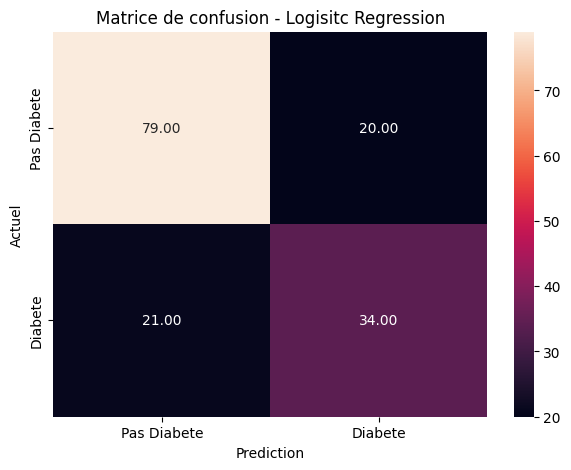

In [58]:

conf_mat = metrics.confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7,5))
sns.heatmap(conf_mat, annot=True, fmt='.2f', xticklabels=['Pas Diabete', 'Diabete'], yticklabels=['Pas Diabete', 'Diabete'])
plt.title("Matrice de confusion - Logisitc Regression")
plt.ylabel('Actuel')
plt.xlabel('Prediction')
plt.show()

Matrice de confusion - K-Nearest Neighbors

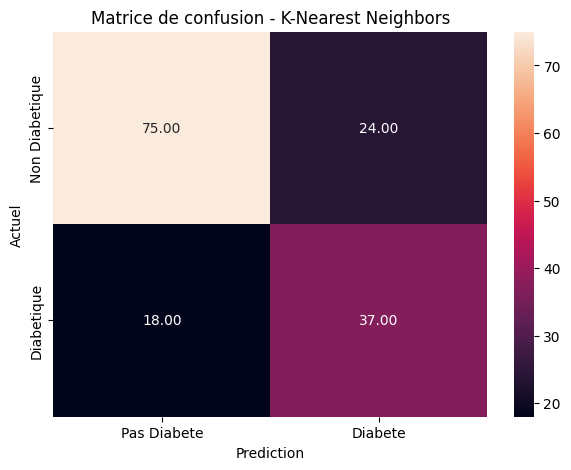

In [65]:

conf_mat = metrics.confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(7,5))
sns.heatmap(conf_mat, annot=True, fmt='.2f', xticklabels=['Pas Diabete', 'Diabete'], yticklabels=['Non Diabetique', 'Diabetique'])
plt.title("Matrice de confusion - K-Nearest Neighbors")
plt.ylabel('Actuel')
plt.xlabel('Prediction')
plt.show()

Matrice de confusion - XGBoost

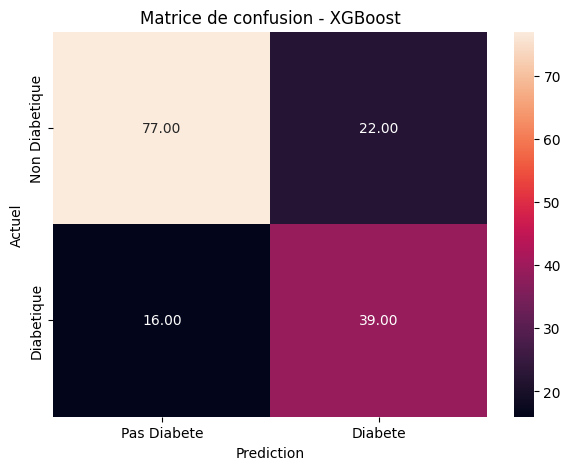

In [64]:

conf_mat = metrics.confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(7,5))
sns.heatmap(conf_mat, annot=True, fmt='.2f', xticklabels=['Pas Diabete', 'Diabete'], yticklabels=['Non Diabetique', 'Diabetique'])
plt.title("Matrice de confusion - XGBoost")
plt.ylabel('Actuel') 
plt.xlabel('Prediction')
plt.show()

Matrice de confusion - Random Forest

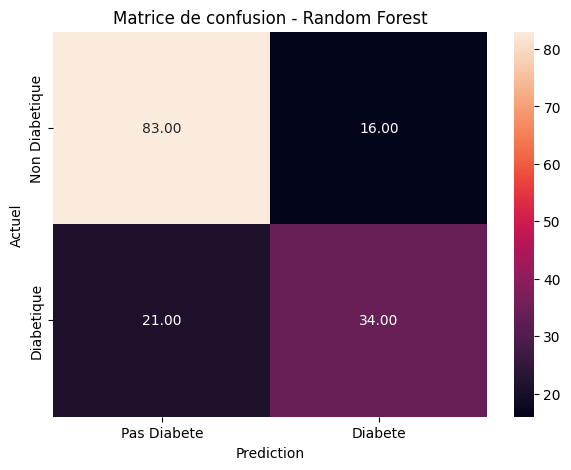

In [66]:

conf_mat = metrics.confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7,5))
sns.heatmap(conf_mat, annot=True, fmt='.2f', xticklabels=['Pas Diabete', 'Diabete'], yticklabels=['Non Diabetique', 'Diabetique'])
plt.title("Matrice de confusion - Random Forest")
plt.ylabel('Actuel') 
plt.xlabel('Prediction')
plt.show()

L’analyse des matrices de confusion montre que le modèle XGBoost est le plus performant. Il présente le plus faible nombre de faux négatifs (16), ce qui est essentiel dans le cadre du diagnostic du diabète, car cela signifie qu’il détecte davantage de patients malades. KNN présente des performances intermédiaires, tandis que la régression logistique et Random Forest affichent le plus grand nombre de faux négatifs (21), indiquant qu’elles manquent un nombre plus important de cas positifs. En conclusion XGBoost est le modèle  le plus adapté parmis ces 3 pour cette problématique.

ANALYSE OBLIGATOIRE

Q--Le dataset est-il équilibré? 

R-- Non il n'est pas équilibré car le nombre de patients non diabétiques est significativement plus élevé que celui des patients diabétiques. Et ce déséquilibre peut influencer les performances des modèles.

Q--Quel type d'erreur est le plus critique dans ce contexte médical?

R-- Dans un contexte médical, les faux négatifs sont les erreurs les plus critiques, car ils correspondent à des patients malades non détectés par le modèle. Cela peut entraîner un retard de diagnostic et de traitement, avec des conséquences potentiellement graves pour la santé des patients.


Q--Le modèle est-il réellement fiable? 
R-- Le modèle XGBoost peut être considéré comme le plus fiable parmi ceux testés, car il présente les meilleures performances globales (accuracy, recall et F1-score) et minimise les erreurs critiques (faux négatifs). Cependant, il n’est pas parfait et continue de produire certaines erreurs. Ainsi, bien qu’il soit le plus adapté dans ce contexte, son utilisation en pratique devrait être accompagnée d’une validation supplémentaire.